In [1]:
# CNN LAB
# Fashion MNIST Dataset
# Load Dataset

import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

from tensorflow.keras.datasets import fashion_mnist

(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

print("=" * 60)
print("ORIGINAL DATASET")
print("=" * 60)

print("Training Images :", len(X_train))
print("Testing Images  :", len(X_test))

# Small dataset for demonstration

X_train = X_train[:200]
y_train = y_train[:200]

X_test = X_test[:20]
y_test = y_test[:20]
print("\nAfter Reduction")
print("Training Images:",len(X_train))
print("Testing Images:",len(X_test))

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 5us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 23s 1us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 4s 1us/step
ORIGINAL DATASET
Training Images : 60000
Testing Images  : 10000

After Reduction
Training Images: 200
Testing Images: 20


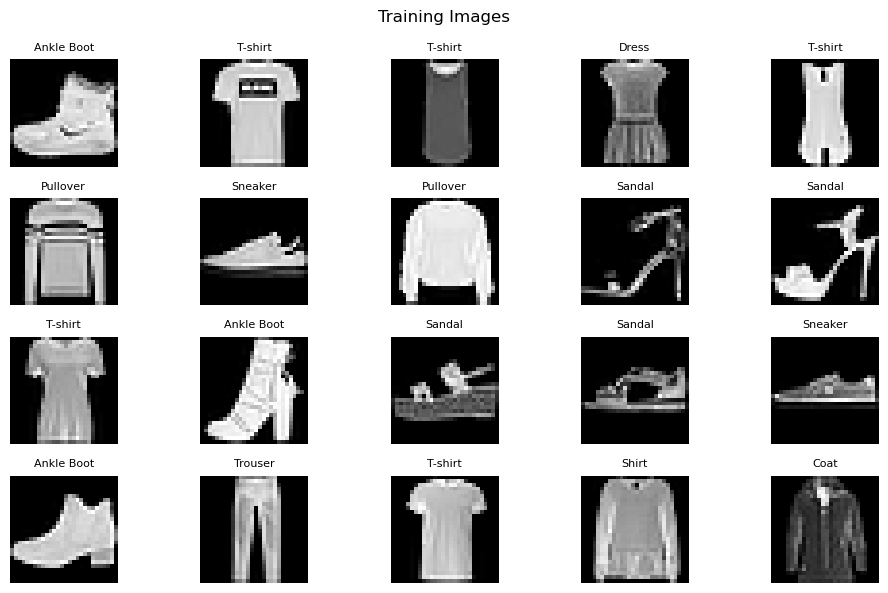

In [3]:
# Fashion MNIST labels
class_names = [
    'T-shirt',
    'Trouser',
    'Pullover',
    'Dress',
    'Coat',
    'Sandal',
    'Shirt',
    'Sneaker',
    'Bag',
    'Ankle Boot'
]

plt.figure(figsize=(10, 6))

for i in range(20):
    plt.subplot(4, 5, i + 1)

    plt.imshow(X_train[i], cmap='gray')
    plt.title(class_names[y_train[i]], fontsize=8)
    plt.axis('off')

plt.suptitle("Training Images")
plt.tight_layout()
plt.show()

In [4]:
X_train=X_train/255.0

X_test=X_test/255.0

X_train=X_train.reshape(-1,28,28,1)

X_test=X_test.reshape(-1,28,28,1)

print(X_train.shape)

(200, 28, 28, 1)


In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense

model = Sequential()

# Input layer
model.add(Input(shape=(28, 28, 1)))

# Convolution layer
model.add(
    Conv2D(
        32,
        (3, 3),
        activation='relu'
    )
)

# Pooling layer
model.add(
    MaxPooling2D(
        pool_size=(2, 2)
    )
)

# Flatten layer
model.add(Flatten())

# Hidden layer
model.add(
    Dense(
        128,
        activation='relu'
    )
)

# Output layer
model.add(
    Dense(
        10,
        activation='softmax'
    )
)

In [11]:
#Show Architecture
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)                    │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_4 (Flatten)                  │ (None, 5408)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 128)                 │         692,352 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 693,962 (2.65 MB)

 Trainable params: 693,962 (2.65 MB)

 Non-trainable params: 0 (0.00 B)

In [21]:
#Compile
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


In [20]:
#Train
history=model.fit(
    X_train,
    y_train,
    epochs=10,
    validation_data=(X_test,y_test)
)


Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.8650 - loss: 0.4052 - val_accuracy: 0.7000 - val_loss: 0.8966
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8850 - loss: 0.3027 - val_accuracy: 0.9000 - val_loss: 0.3507
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9300 - loss: 0.1994 - val_accuracy: 0.8000 - val_loss: 0.6246
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9600 - loss: 0.1653 - val_accuracy: 0.8500 - val_loss: 0.4299
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9650 - loss: 0.1412 - val_accuracy: 0.9000 - val_loss: 0.4341
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9750 - loss: 0.1141 - val_accuracy: 0.9000 - val_loss: 0.4676
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9750 - loss: 0.0933 - val_accuracy: 0.8500 - val_loss: 0.4895
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9950 - loss: 0.0771 - val_accuracy: 0.9000 - val_loss: 0.4257


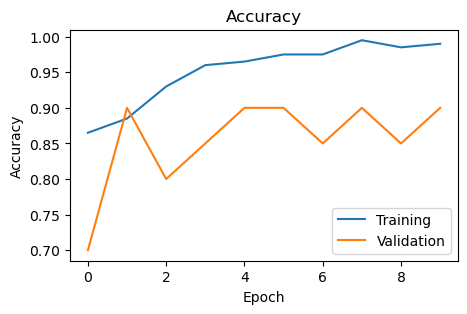

In [22]:
#Accuracy Curve

plt.figure(figsize=(5, 3))

plt.plot(history.history['accuracy'], label='Training')
plt.plot(history.history['val_accuracy'], label='Validation')

plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()

plt.show()


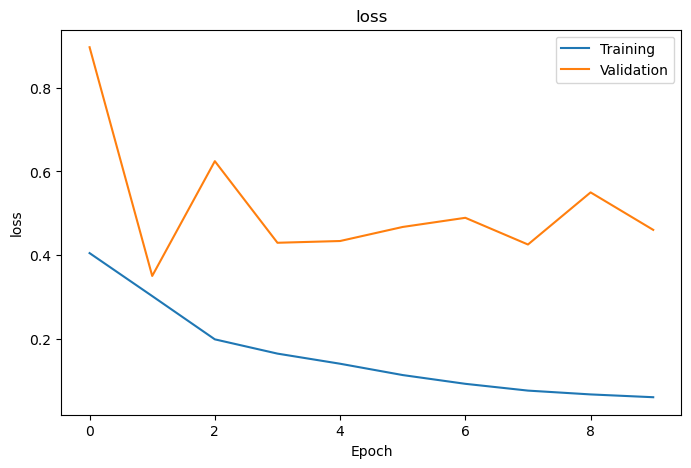

In [23]:
#Loss Curve
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'],label='Training')
plt.plot(history.history['val_loss'],label='Validation')
plt.title("loss")
plt.xlabel("Epoch")
plt.ylabel("loss")
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step


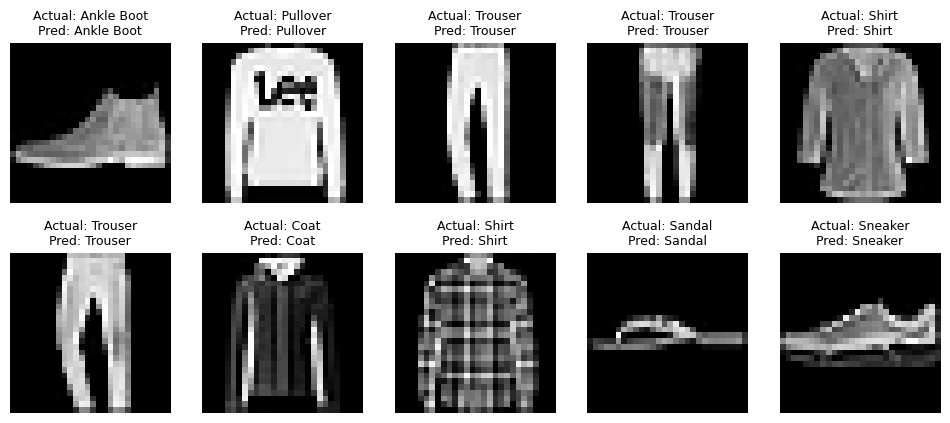

In [24]:
#Prediction
prediction = model.predict(X_test)

predicted = np.argmax(prediction, axis=1)

plt.figure(figsize=(12, 5))

for i in range(10):

    plt.subplot(2, 5, i + 1)

    plt.imshow(X_test[i].reshape(28, 28), cmap='gray')

    plt.title(
        "Actual: " + class_names[y_test[i]] +
        "\nPred: " + class_names[predicted[i]],
        fontsize=9
    )

    plt.axis("off")

plt.show()